# Basic MCMC
Part of the Bayesian neural networks via MCMC: a Python-based tutorial

This section of the tutorial covers the development of a basic MCMC algorithm.
This example takes inspiration from [this blog post](https://towardsdatascience.com/bayesian-inference-and-markov-chain-monte-carlo-sampling-in-python-bada1beabca7) with some simplifications and notation updated to align with the accompanying tutorial.

### Imports

In [1]:
import numpy as np
from numpy import random
from tqdm import tqdm
from scipy import stats
# visulisation function
from functions.visualisations import histogram_trace

## Define the functions required for MCMC sampling

We will start with the simplest example, sampling the posterior of a single parameter.
In this example, we are trying to obtain information about the probability of success given some data of `k` successes in `n` trials using an uninformative prior.

This type of problem is represented by a binomial distribution and we will be solving for the posterior distribution of parameter `p` (probability of success) in this distribution.

First, we need to define the likelihood function given our data (`k`,`n`).

In [2]:
# First define our likelihood function which will be dependent on provided `data`
def generate_likelihood(k, n):
    '''
    Given the data of k successes in n trials, return a likelihood function which 
    evaluates the probability that a single success (p) is query_prob for any given 
    query_prob (between 0 and 1).
    This is defined by a binomial distribution. 
    See: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html
    L(p|k, n) = C(n, k) * p^k * (1-p)^(n - k)
    '''
    def likelihood(query_prob):
        print(query_prob)
        print("k: ", k)
        print("n: ", n)
        print("binom.pmf: ", stats.binom.pmf(k, n, query_prob))
        return stats.binom.pmf(k, n, query_prob)
    return likelihood

In [3]:
generate_likelihood(5, 10)(0.5)

0.5
k:  5
n:  10
binom.pmf:  0.24609375


np.float64(0.24609375)

## Sample using MCMC

- Create the MCMC loop and sample the posterior distribution
- We will use an un-informative (changed to un-informative, as the prior is uniform), uniform prior - $Pr(p) = 1$ for $p \in [0,1]$
###### every value p can take between 0 and 1 is equally likely, probability that p is between 0.2 and 0.3 is as same as the probability between 0.7 and 0.8 being 0.1%
- With this symmetric prior(no directional bias)  and the proposal `p` between 0 and 1, the contribution of the proposal distribution (which suggests a new candidate value xi for the next sample, given the current sample x') to the MH acceptance ratio is always:

$$\frac{q(x_i \mid x')}{q(x' \mid x_i)} = 1$$

- We therefore only need to compare the likelihood of the proposed and current sample 
$$ \frac{P(x')}{P(x_i)} = ?$$

In [4]:
## MCMC Settings and Setup
n_samples = 10000 # number of samples to draw from the posterior
burn_in = 2500 # number of samples to discard before recording draws from the posterior
# MCMC chains often start with poor or biased samples as the algorithm needs time to explore and
# converge to the true posterior. 
# Here, the first 2500 samples are thrown away and only the remaining 7500 samples are kept for analysis.

# specify our `data` for this example ensuring k <= n
binom_k = 50 # number of successes
binom_n = 100 # in n trials

x = random.uniform(0, 1) # initialise a value of x0
count = 0 # count the number of accepted samples

In [5]:
# Build the likelihood function for the binomial model using the observed data:
# binom_k = number of observed successes, binom_n = number of trials.
likelihood_function = generate_likelihood(binom_k, binom_n)

# Create an empty array to store the MCMC samples of the unknown parameter p.
# Each entry will later hold one sampled value from the posterior distribution.
p_posterior = np.full(n_samples, np.nan) 

print('Generating {} MCMC samples from the posterior:'.format(n_samples))

# Run the Metropolis-Hastings MCMC sampler for n_samples iterations.
for ii in tqdm(np.arange(n_samples)):

    # Propose a new candidate value for p by sampling uniformly between 0 and 1.
    # This works because p is a probability, so it must lie in [0, 1].
    x_new = random.uniform(0, 1)

    # Compute how much more likely the proposed value is compared to the current value.
    # Since the prior is uniform/simple here, the prior ratio is 1 and does not affect acceptance.
    prior_ratio = 1
    likelihood_ratio = likelihood_function(x_new) / likelihood_function(x)

    # Calculate the Metropolis-Hastings acceptance probability.
    # If the proposal is more likely than the current value, alpha becomes 1.
    # If it is less likely, alpha is the likelihood ratio.
    alpha = np.min([1, likelihood_ratio * prior_ratio])

    # Draw a random number u from Uniform(0, 1).
    # Accept the proposal if u is less than alpha.
    # This means better proposals are usually accepted, but worse proposals can still be accepted sometimes.
    u = random.uniform(0, 1)
    if u < alpha:
        x = x_new      # Move to the proposed value.
        count += 1     # Track how many proposals were accepted.

    # Store the current value of x as one posterior sample.
    # If the proposal was rejected, this stores the previous value again.
    p_posterior[ii] = x

# Report the percentage of proposed moves that were accepted.
print('Acceptance rate: {:.2f}%'.format(count / n_samples * 100))

# Print the full array of posterior samples.
print("All posterior samples:")
print(p_posterior)

print('Done')

# After the loop, p_posterior contains MCMC samples approximating the posterior
# distribution of the binomial probability p given the observed data k and n.


Generating 10000 MCMC samples from the posterior:


  0%|          | 0/10000 [00:00<?, ?it/s]

  1%|          | 58/10000 [00:00<00:17, 576.07it/s]

0.6070971612766608
k:  50
n:  100
binom.pmf:  0.007603654028006724
0.013402382052767114
k:  50
n:  100
binom.pmf:  1.1747805127435001e-65
0.6663814094051651
k:  50
n:  100
binom.pmf:  0.00022516957592636552
0.6070971612766608
k:  50
n:  100
binom.pmf:  0.007603654028006724
0.007121665843193625
k:  50
n:  100
binom.pmf:  3.0042441086565604e-79
0.6070971612766608
k:  50
n:  100
binom.pmf:  0.007603654028006724
0.9395593142270247
k:  50
n:  100
binom.pmf:  5.2063479150228925e-34
0.6070971612766608
k:  50
n:  100
binom.pmf:  0.007603654028006724
0.7719680133288027
k:  50
n:  100
binom.pmf:  1.9213555452280516e-09
0.6070971612766608
k:  50
n:  100
binom.pmf:  0.007603654028006724
0.5964271060528469
k:  50
n:  100
binom.pmf:  0.011962501416065746
0.6070971612766608
k:  50
n:  100
binom.pmf:  0.007603654028006724
0.9708167123774262
k:  50
n:  100
binom.pmf:  4.14406808730573e-49
0.5964271060528469
k:  50
n:  100
binom.pmf:  0.011962501416065746
0.9491143182115833
k:  50
n:  100
binom.pmf:  1.

  1%|          | 120/10000 [00:00<00:16, 593.00it/s]

...

0.6001559096768732
k:  50
n:  100
binom.pmf:  0.010270517638288014
0.5651557085046168
k:  50
n:  100
binom.pmf:  0.03380247506480429
0.3086831993246071
k:  50
n:  100
binom.pmf:  2.906425006776058e-05
0.5651557085046168
k:  50
n:  100
binom.pmf:  0.03380247506480429
0.8203196021886272
k:  50
n:  100
binom.pmf:  2.679436112241867e-13
0.5651557085046168
k:  50
n:  100
binom.pmf:  0.03380247506480429
0.31197921777193394
k:  50
n:  100
binom.pmf:  3.892377771686627e-05
0.5651557085046168
k:  50
n:  100
binom.pmf:  0.03380247506480429
0.9850105128596568
k:  50
n:  100
binom.pmf:  2.9190120491737683e-63
0.5651557085046168
k:  50
n:  100
binom.pmf:  0.03380247506480429
0.9167310889203797
k:  50
n:  100
binom.pmf:  1.3806899539611005e-27
0.5651557085046168
k:  50
n:  100
binom.pmf:  0.03380247506480429
0.04546986993274893
k:  50
n:  100
binom.pmf:  7.577423922776177e-40
0.5651557085046168
k:  50
n:  100
binom.pmf:  0.03380247506480429
0.5611064267172726
k:  50
n:  100
binom.pmf:  0.03750396072

 99%|█████████▉| 9935/10000 [00:13<00:00, 708.94it/s]

binom.pmf:  0.028423044354024183
0.15552314192660954
k:  50
n:  100
binom.pmf:  8.375150444628882e-16
0.5713844753468439
k:  50
n:  100
binom.pmf:  0.028423044354024183
0.8514148803142998
k:  50
n:  100
binom.pmf:  1.2873055400745555e-16
0.5713844753468439
k:  50
n:  100
binom.pmf:  0.028423044354024183
0.3729155366007044
k:  50
n:  100
binom.pmf:  0.00282279818645141
0.5713844753468439
k:  50
n:  100
binom.pmf:  0.028423044354024183
0.7760797600763665
k:  50
n:  100
binom.pmf:  1.0088795411385688e-09
0.5713844753468439
k:  50
n:  100
binom.pmf:  0.028423044354024183
0.031973866296727604
k:  50
n:  100
binom.pmf:  3.4511651440986346e-47
0.5713844753468439
k:  50
n:  100
binom.pmf:  0.028423044354024183
0.2942758155986879
k:  50
n:  100
binom.pmf:  7.470205281335303e-06
0.5713844753468439
k:  50
n:  100
binom.pmf:  0.028423044354024183
0.5890893089731832
k:  50
n:  100
binom.pmf:  0.01585926311295027
0.5713844753468439
k:  50
n:  100
binom.pmf:  0.028423044354024183
0.9830324497101365
k

100%|██████████| 10000/10000 [00:13<00:00, 718.51it/s]

Acceptance rate: 16.34%
All posterior samples:
[0.60709716 0.60709716 0.60709716 ... 0.46967489 0.53258551 0.53258551]
Done


## Analyse the results
Plot the posterior distribution and trace

In [6]:
# print(results, 'results')
per_accept = (count/n_samples)*100
print('{:.3f} % accepted'.format(per_accept))
posterior_mean = np.mean(p_posterior[burn_in:])
print('{:.3f} mean value of posterior'.format(posterior_mean))

16.340 % accepted
0.503 mean value of posterior


[0.         0.001001   0.002002   0.003003   0.004004   0.00500501
 0.00600601 0.00700701 0.00800801 0.00900901 0.01001001 0.01101101
 0.01201201 0.01301301 0.01401401 0.01501502 0.01601602 0.01701702
 0.01801802 0.01901902 0.02002002 0.02102102 0.02202202 0.02302302
 0.02402402 0.02502503 0.02602603 0.02702703 0.02802803 0.02902903
 0.03003003 0.03103103 0.03203203 0.03303303 0.03403403 0.03503504
 0.03603604 0.03703704 0.03803804 0.03903904 0.04004004 0.04104104
 0.04204204 0.04304304 0.04404404 0.04504505 0.04604605 0.04704705
 0.04804805 0.04904905 0.05005005 0.05105105 0.05205205 0.05305305
 0.05405405 0.05505506 0.05605606 0.05705706 0.05805806 0.05905906
 0.06006006 0.06106106 0.06206206 0.06306306 0.06406406 0.06506507
 0.06606607 0.06706707 0.06806807 0.06906907 0.07007007 0.07107107
 0.07207207 0.07307307 0.07407407 0.07507508 0.07607608 0.07707708
 0.07807808 0.07907908 0.08008008 0.08108108 0.08208208 0.08308308
 0.08408408 0.08508509 0.08608609 0.08708709 0.08808809 0.0890

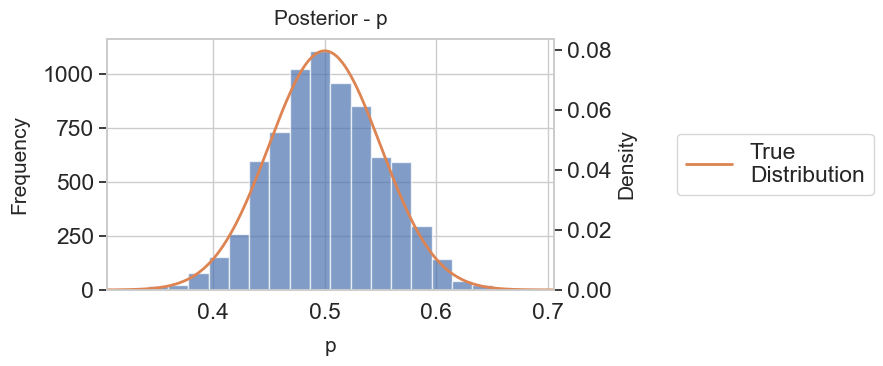

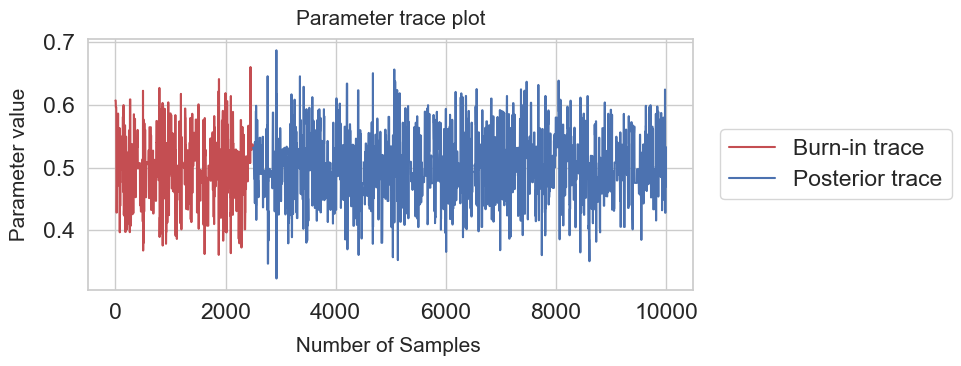

In [7]:
histogram_trace(
    p_posterior, 
    true_posterior = np.vstack([np.linspace(0,1,1000),likelihood_function(np.linspace(0,1,1000))]).T, 
    burn_in = burn_in,
    title='Posterior - p',
    param_name = 'p',
    # fname='figures/02-Basic-MCMC'  
)
# np.linspace(0,1,1000) creates an array of 1000 evenly spaced values between 0 and 1, 
# which are used as input to the likelihood function.
# The sampler proposes many values of p in [0,1] uniformly at random, 
# but only accepts those that are more li(or with some probability if they are less likely).

In [8]:
# This plot shows the posterior distribution of the parameter p.
#
# In this example, p represents an unknown probability parameter, such as the
# probability of success in a Bernoulli or binomial experiment. Since p is a
# probability, its possible values lie between 0 and 1.
#
# The blue histogram represents posterior samples of p generated by the MCMC
# sampler. Each sampled value is one possible value of p that is consistent
# with the observed data and the prior assumptions. The x-axis shows the value
# of p, while the left y-axis shows the frequency, meaning how many MCMC samples
# fall into each interval or bin of p.
#
# The tallest bars occur near p = 0.5. This means the MCMC sampler visited
# values around 0.5 most often, so values close to 0.5 have the highest posterior
# probability. In practical terms, the data suggest that the probability of
# success is close to 50%.
#
# Values further away from 0.5, such as p = 0.35 or p = 0.65, appear much less
# frequently. These values are still possible, but they are less credible given
# the observed data. The posterior distribution therefore expresses uncertainty:
# p is probably near 0.5, but there is still some probability assigned to nearby
# values.
#
# The orange curve represents the true/theoretical posterior distribution.
# Unlike the histogram, it uses the right y-axis, labelled Density. A density is
# scaled so that the total area under the curve equals 1. This is why the
# histogram frequency scale and the density scale are different.
#
# The close agreement between the blue histogram and the orange curve shows that
# the MCMC sampler is working well. The sampled posterior values approximate the
# true posterior distribution closely. If the MCMC sampler were poor, the blue
# bars would not follow the shape of the orange curve.
#
# The posterior is approximately bell-shaped and centered around p = 0.5. This
# indicates that the data provide balanced evidence for success and failure.
# For example, if the observed data contained roughly equal numbers of successes
# and failures, then the most plausible value of p would naturally be close to
# 0.5.
#
# Overall, this graph demonstrates that:
# 1. The most likely value of p is around 0.5.
# 2. The posterior uncertainty is moderate, with most plausible values lying
#    roughly between 0.42 and 0.58.
# 3. Extreme values of p are unlikely because they are inconsistent with the
#    observed data.
# 4. The MCMC samples successfully approximate the true posterior distribution.


In [9]:
# This figure is a trace plot for the sampled parameter value, p.
#
# A trace plot shows the value sampled by the MCMC algorithm at each iteration.
# The x-axis represents the sample number or iteration number, while the y-axis
# represents the sampled value of the parameter at that iteration.
#
# The red section is the burn-in trace. Burn-in refers to the early part of the
# MCMC chain, before we fully trust that the sampler has settled into the target
# posterior distribution. These early samples are usually discarded because they
# may still be influenced by the initial starting value of the chain.
#
# The blue section is the posterior trace. These are the samples kept after the
# burn-in period. They are treated as samples from the posterior distribution of
# the parameter.
#
# In this plot, the parameter values fluctuate mostly around p = 0.5. This
# agrees with the posterior histogram, where the highest posterior probability
# was also around p = 0.5. The sampler repeatedly moves above and below 0.5,
# which is expected because MCMC explores a distribution rather than returning
# one fixed estimate.
#
# The chain does not show a strong upward or downward trend after burn-in.
# Instead, the blue trace forms a roughly stable horizontal band. This is a good
# sign because it suggests that the sampler has reached a stationary distribution
# and is no longer drifting toward a different region.
#
# The vertical spread of the trace, roughly from about 0.35 to 0.65, represents
# posterior uncertainty. Values near 0.5 occur frequently, while more extreme
# values are visited less often. This means the model considers p close to 0.5
# most plausible, but still allows some uncertainty around that estimate.
#
# The trace also appears to mix reasonably well: the sampled values move around
# the posterior region instead of getting stuck at one value for a long time.
# Good mixing is important because it means the MCMC sampler is exploring the
# posterior distribution effectively.
#
# Overall, this trace plot suggests that:
# 1. The burn-in samples should be discarded because they belong to the initial
#    adaptation/exploration phase of the chain.
# 2. After burn-in, the chain appears stable and centered around p = 0.5.
# 3. There is no obvious long-term trend in the posterior trace, which supports
#    the idea that the chain has converged.
# 4. The posterior samples fluctuate within a reasonable range, showing both the
#    most likely parameter region and the uncertainty around it.
# 5. The MCMC sampler appears to be sampling from the intended posterior
#    distribution rather than drifting or becoming stuck.
